# Load, Infer, and Push

Load a trained experiment from disk, run inference on an empirical batch, and push either the native training artifact export or the separate consumer-facing runtime bundle to the Hugging Face Hub.


In [5]:
from pathlib import Path
from typing import Optional, Sequence

from huggingface_hub import HfApi
from matplotlib import pyplot as plt

from pff import config_dir
from pff.data.data_empirical.builder import prediction_to_study_jsons
from pff.hub_runtime import push_loaded_model_runtime_bundle
from pff.training.basic_experiment import BasicLightningExperiment
from pff.utils.plots.databatch_plot import plot_study_json_with_prediction


In [6]:
def _default_model_card_path() -> list[str]:
    return ["hf_model_cards", "AICME-PK_Readme.md"]


def _default_repo_name(experiment: BasicLightningExperiment) -> str:
    if experiment.exp_config is None:
        raise RuntimeError("Experiment config is not loaded.")
    return str(experiment.exp_config.hf_model_name)


def _default_repo_id(
    experiment: BasicLightningExperiment,
    repo_name: Optional[str] = None,
) -> str:
    if experiment.hf_token is None:
        raise RuntimeError(
            "No Hugging Face token available. Set hugging_face_token in the config or KEYS.txt."
        )
    user = HfApi().whoami(token=experiment.hf_token)["name"]
    resolved_repo_name = repo_name or _default_repo_name(experiment)
    return f"{user}/{resolved_repo_name}"


def _default_runtime_repo_name(experiment: BasicLightningExperiment) -> str:
    return f"{_default_repo_name(experiment)}-runtime"


def load_local_experiment(
    experiment_dir: str,
    checkpoint_type: str = "best",
    map_location: str = "cpu",
) -> BasicLightningExperiment:
    """Load a previously trained experiment directly from its local folder."""
    experiment = BasicLightningExperiment.from_experiment_dir(
        experiment_dir=experiment_dir,
        checkpoint_type=checkpoint_type,
        map_location=map_location,
    )
    return experiment


def push_loaded_model(
    experiment: BasicLightningExperiment,
    model_card_path: Optional[Sequence[str]] = None,
    hf_repo_id: Optional[str] = None,
    repo_name: Optional[str] = None,
    alias_name: str = "best_model_hf",
    commit_message: str = "manual notebook push",
) -> str:
    """Push the already loaded model using the experiment's internal HF helper.

    Notes
    -----
    `alias_name` only controls the local staging folder inside the experiment
    directory. The user-visible model name on the Hub is determined by
    `hf_repo_id` (or by `repo_name` when `hf_repo_id` is omitted).
    """
    if experiment.model is None:
        raise RuntimeError("Experiment model is not loaded.")
    if experiment.exp_config is None:
        raise RuntimeError("Experiment config is not loaded.")
    if experiment.experiment_dir is None:
        raise RuntimeError("Experiment directory is required before pushing.")
    if experiment.hf_token is None:
        raise RuntimeError(
            "No Hugging Face token available. Set hugging_face_token in the config or KEYS.txt."
        )

    if model_card_path is not None:
        normalized_model_card_path = tuple(model_card_path)
        experiment.exp_config.hf_model_card_path = normalized_model_card_path
        if hasattr(experiment.model, "config"):
            experiment.model.config.hf_model_card_path = normalized_model_card_path

        local_model_card_path = Path(config_dir).joinpath(*normalized_model_card_path)
        if not local_model_card_path.is_file():
            raise FileNotFoundError(f"Model card not found at: {local_model_card_path}")

    if hf_repo_id is None:
        hf_repo_id = _default_repo_id(experiment, repo_name=repo_name)

    experiment._push_model_to_hub(
        model=experiment.model,
        hf_repo_id=hf_repo_id,
        commit_message=commit_message,
        alias_name=alias_name,
    )
    return hf_repo_id


def push_loaded_model_runtime_bundle_notebook(
    experiment: BasicLightningExperiment,
    model_card_path: Optional[Sequence[str]] = None,
    hf_repo_id: Optional[str] = None,
    repo_name: Optional[str] = None,
    alias_name: str = "runtime_bundle_hf",
    commit_message: str = "manual runtime bundle push",
) -> str:
    """Push the separate consumer-facing runtime bundle for a loaded experiment."""
    resolved_repo_id = hf_repo_id
    if resolved_repo_id is None and repo_name is not None:
        resolved_repo_id = _default_repo_id(experiment, repo_name=repo_name)
    return push_loaded_model_runtime_bundle(
        experiment=experiment,
        model_card_path=model_card_path,
        hf_repo_id=resolved_repo_id,
        alias_name=alias_name,
        commit_message=commit_message,
    )


## User Configuration

Point `EXPERIMENT_DIR` to a finished experiment folder. Override `MODEL_CARD_PATH` when you want to push a different local README, for example `['hf_model_cards', 'AICME-PK_Readme.md']`.

In [7]:
EXPERIMENT_DIR = "/home/cesarali/Pharma/pff/results/grim_capital/"
CHECKPOINT_TYPE = "last"
MAP_LOCATION = "cpu"

MODEL_CARD_PATH = _default_model_card_path()

# User-visible Hub model name. When None, the loaded experiment's current
# `exp_config.hf_model_name` is used.
HF_MODEL_NAME = "AICME"
# Full Hub repo id. When None, defaults to your current HF user plus
# `HF_MODEL_NAME` (or the loaded experiment's configured model name).
HF_REPO_ID = None
ALIAS_NAME = "best_model_hf"
COMMIT_MESSAGE = "manual notebook push from load_and_push.ipynb"

# Separate consumer runtime repo. When None, the default becomes
# `<your-user>/<HF_MODEL_NAME>-runtime` after the experiment is loaded.
HF_RUNTIME_MODEL_NAME = None
HF_RUNTIME_REPO_ID = None
RUNTIME_ALIAS_NAME = "runtime_bundle_hf"
RUNTIME_COMMIT_MESSAGE = "manual runtime bundle push from load_and_push.ipynb"

SAMPLE_SIZE = 10

Path(EXPERIMENT_DIR)


PosixPath('/home/cesarali/Pharma/pff/results/grim_capital')

In [8]:
experiment = load_local_experiment(
    experiment_dir=EXPERIMENT_DIR,
    checkpoint_type=CHECKPOINT_TYPE,
    map_location=MAP_LOCATION,
)

model = experiment.model.to("cpu")
experiment_dm = experiment.datamodule
experiment_dm.setup()

if hasattr(experiment_dm, "fix_past_selection"):
    experiment_dm.fix_past_selection(5)

all_empirical_batches = experiment_dm.get_empirical_test_batches()
study_name = next(iter(all_empirical_batches))
batch_list = all_empirical_batches[study_name]
one_batch = batch_list[0]

experiment.exp_config.hf_model_card_path, study_name, len(batch_list)


CometLogger will be initialized in online mode


(('hf_model_cards', 'AICME-PK_Readme.md'), 'cesarali/lenuzza-2016', 10)

In [9]:
resolved_hf_model_name = HF_MODEL_NAME or _default_repo_name(experiment)
resolved_hf_repo_id = HF_REPO_ID or _default_repo_id(experiment, repo_name=resolved_hf_model_name)

resolved_runtime_model_name = HF_RUNTIME_MODEL_NAME or f"{resolved_hf_model_name}-runtime"
resolved_runtime_repo_id = HF_RUNTIME_REPO_ID or _default_repo_id(
    experiment,
    repo_name=resolved_runtime_model_name,
)

print("Native Hub model name:", resolved_hf_model_name)
print("Native Hub repo id:", resolved_hf_repo_id)
print("Runtime Hub model name:", resolved_runtime_model_name)
print("Runtime Hub repo id:", resolved_runtime_repo_id)
print("ALIAS_NAME is only a local staging folder name:", ALIAS_NAME)


Native Hub model name: AICME
Native Hub repo id: cesarali/AICME
Runtime Hub model name: AICME-runtime
Runtime Hub repo id: cesarali/AICME-runtime
ALIAS_NAME is only a local staging folder name: best_model_hf


In [10]:
sampled_trajectories, sampled_trajectories_time, real_trajectories, mask_real_trajectories = model.sample_individual_prediction(
    one_batch,
    sample_size=SAMPLE_SIZE,
)
study_list = prediction_to_study_jsons(
    sampled_trajectories,
    sampled_trajectories_time,
    one_batch,
    model.meta_dosing,
)
study = study_list[0]
study["meta_data"]["substance_name"]


'memantine'

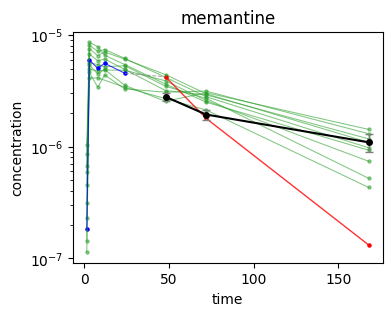

In [11]:
%matplotlib inline
drug_name = study["meta_data"]["substance_name"]
fig, ax = plt.subplots(figsize=(4, 3))
ax.set_title(drug_name)
plot_study_json_with_prediction(study, ax=ax, log_scale=True)
plt.show()


## Push to Hugging Face

Use the first push cell for the existing native training export. Use the second push cell for the separate consumer-facing runtime bundle repo. `HF_MODEL_NAME` and `HF_RUNTIME_MODEL_NAME` control the user-visible Hub repo names. `ALIAS_NAME` and `RUNTIME_ALIAS_NAME` only control the local staging folder names inside the experiment directory.


In [12]:
hf_repo_id = push_loaded_model(
    experiment=experiment,
    model_card_path=MODEL_CARD_PATH,
    hf_repo_id=resolved_hf_repo_id,
    repo_name=resolved_hf_model_name,
    alias_name=ALIAS_NAME,
    commit_message=COMMIT_MESSAGE,
)
hf_repo_id


Uploading...:   0%|          | 0.00/37.5M [00:00<?, ?B/s]

'cesarali/AICME'

In [14]:
runtime_repo_id = push_loaded_model_runtime_bundle_notebook(
    experiment=experiment,
    model_card_path=MODEL_CARD_PATH,
    hf_repo_id=resolved_runtime_repo_id,
    repo_name=resolved_runtime_model_name,
    alias_name=RUNTIME_ALIAS_NAME,
    commit_message=RUNTIME_COMMIT_MESSAGE,
)
runtime_repo_id


Uploading...:   0%|          | 0.00/37.5M [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


'cesarali/AICME-runtime'